# DAAAnalyzer_3.0_ThresholdShiftCalc_2TP.ipynb
Created by: JFranco | Created On: 26 DEC 2024 | Last Env: QISHA | Last Run Date: 3 JAN 2025

This Python notebook analyzes the threshold shift and changes in wave one amplitudes between two time points. 
It generates a .csv file that has the calculated DPOAE and ABR threshold shifts for each animal, and then 
descriptive statistics between groups. 

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import glob
import os
import xlrd
import math
import matplotlib.pyplot as plt

In [2]:
# Parameters for plotting
conditions = ["HABclw","CtrlInj","UnInj"]
pltOrder = conditions
colors = {pltOrder[0]:'goldenrod' , pltOrder[1]:'slateblue', pltOrder[2]:'mediumorchid'}
legColors = ["goldenrod", "slateblue","mediumorchid"]

In [3]:
# *** WHAT TO ANALYZE // WHERE TO GET/STORE **
# Key identifiers
prepID = 'CMI_005'
daaRuns = [1,3]
#fnMD = prepID+'.Metadata.AnimalInfo.csv'

# Directories 
#   - Existing ones - 
dirMain = '/Users/joyfranco/Dropbox (Partners HealthCare)/JF_Shared/Data/CFTS/'
dirPrep = dirMain+prepID+'/'
#dirData = dirPrep+'RawData/'
#dirMD = dirPrep+'Metadata/'
dirSV = dirPrep+'Results/'
dirDFs = dirSV+"1_CompiledMeasurements/"
dirDPOAEs = dirSV+"2_DPOAEPlotsByGroup/"
#dirSjABRPlts = dirSV+"3_ABRPlotsBySubject/"
dirGpABRPlts = dirSV+"4_ABRPlotsByGroup/"
#dirSjWOPlts = dirSV+"5_Wave1PlotsBySubject/"
dirGpWOPlts = dirSV+"6_Wave1PlotsByGroup/"

# Filenames
#    - Existing ones -
#fnMD = prepID+'.Metadata.AnimalInfo.csv'
fnBaseDPs = '.DPOAEf2Thresholds.DAA_'
fnBaseABRs = '.ABRThresholds.DAA_'

#    - Ones that will be made - 
fnDPShifts = prepID+'.DPOAEThresholdShifts.csv'
fnABRShifts = prepID+'.GroupABRStats.csv'

In [4]:
#    *** LOAD THRESHOLD SHEETS **
dfDPThs = pd.DataFrame()
dfABRThs = pd.DataFrame()
for i in range(len(daaRuns)):
    dfDP = pd.read_csv(dirDFs+prepID+fnBaseDPs+str(daaRuns[i])+'.csv')
    dfABR = pd.read_csv(dirDFs+prepID+fnBaseABRs+str(daaRuns[i])+'.csv')
    dfDPThs = pd.concat([dfDPThs, dfDP])
    dfABRThs = pd.concat([dfABRThs, dfABR])
dfDPThs.drop(['Unnamed: 0'], axis=1, inplace=True)
dfABRThs.drop(['Unnamed: 0','level_0','index'], axis=1, inplace=True)

In [5]:
# *** CALCULATE DPOAE THRESHOLD SHIFTS ***
# Iterate through all of the animals
dfDPShifts = pd.DataFrame()
for an in dfDPThs['AnimalID'].unique():
    # Iterate through the number of shifts to calculate
    for i in range(len(daaRuns)-1):
        # Iterate through the frequencies  
        freqs = dfDPThs[(dfDPThs['AnimalID']==an) & (dfDPThs['DAA_Run']==daaRuns[i+1])]['f2Freq_kHz']
        for freq in freqs:
            # Get the threshold for this animal/freq combo at the next DAA_Run
            thSt = dfDPThs[(dfDPThs['AnimalID']==an) & (dfDPThs['DAA_Run']==daaRuns[i])&(dfDPThs['f2Freq_kHz']==freq)]['Thresh_dBSPL'].values[0]
            thEnd = dfDPThs[(dfDPThs['AnimalID']==an) & (dfDPThs['DAA_Run']==daaRuns[i+1])& (dfDPThs['f2Freq_kHz']==freq)]['Thresh_dBSPL'].values[0]
            thShift = thEnd - thSt
            if (len(daaRuns)==2):
                # There are only two time points and the final threshold shift is just the thShift
                thShiftFinal = thShift
            elif ((len(daaRuns)>2)&(i == (len(daaRuns)-2))):
                # This is the final calculation 
                thSt = dfDPThs[(dfDPThs['AnimalID']==an) & (dfDPThs['DAA_Run']==1)& (dfDPThs['f2Freq_kHz']==freq)]['Thresh_dBSPL'].values[0]
                thShiftFinal = thEnd-thSt

            # Create a subset of the original df to build on 
            dfSS = dfDPThs[(dfDPThs['AnimalID']==an) & (dfDPThs['DAA_Run']==i+1)&(dfDPThs['f2Freq_kHz']==freq)].copy()
            dfSS['Shift_'+str(i+1)+'to'+str(i+2)] = thShift
            dfSS['Shift_Final'] = thShiftFinal 
            dfDPShifts = pd.concat([dfDPShifts, dfSS])

In [6]:
dfDPShifts = dfDPShifts.drop(['AnimalID','CMIID','DAA_Run','Sex','Thresh_dBSPL'], axis=1)
grpTh = dfDPShifts.groupby(['InjGroup', 'f2Freq_kHz'])
grpTh.describe()
#grpThStats = grpTh.describe()
#grpThStats.to_csv(dirDFs+fnGBABRs, index=True)

Shift_1to2                                           \
                         count       mean        std   min    25%   50%   
InjGroup f2Freq_kHz                                                       
CtrlInj  5                 3.0   0.000000   0.000000   0.0   0.00   0.0   
         8                 3.0  -2.666667   4.618802  -8.0  -4.00   0.0   
         11                3.0   0.666667   8.082904  -8.0  -3.00   2.0   
         16                3.0   8.333333  12.096832  -1.0   1.50   4.0   
         22                3.0   6.000000  10.392305   0.0   0.00   0.0   
         32                3.0  23.666667  11.015141  13.0  18.00  23.0   
         42                3.0  13.666667  14.571662   0.0   6.00  12.0   
HABclw   5                 3.0   0.000000   0.000000   0.0   0.00   0.0   
         8                 3.0   0.000000   0.000000   0.0   0.00   0.0   
         11                3.0  -7.333333   9.504385 -17.0 -12.00  -7.0   
         16                3.0   2.666667   4.932883  -3.0   1.00   5.0   
         22                3.0   1.000000   7.549834  -7.0  -2.50   2.0   
         32                3.0  -1.666667  11.547005 -15.0  -5.00   5.0   
         42                3.0   2.333333   4.041452   0.0   0.00   0.0   
UnInj    5                 2.0   0.000000   0.000000   0.0   0.00   0.0   
         8                 2.0   0.000000   0.000000   0.0   0.00   0.0   
         11                2.0  12.000000  21.213203  -3.0   4.50  12.0   
         16                2.0  16.000000  26.870058  -3.0   6.50  16.0   
         22                2.0   3.000000  12.727922  -6.0  -1.50   3.0   
         32                2.0   7.500000  31.819805 -15.0  -3.75   7.5   
         42                2.0  10.000000  14.142136   0.0   5.00  10.0   

                                 Shift_Final                              \
                       75%   max       count       mean        std   min   
InjGroup f2Freq_kHz                                                        
CtrlInj  5            0.00   0.0         3.0   0.000000   0.000000   0.0   
         8            0.00   0.0         3.0  -2.666667   4.618802  -8.0   
         11           5.00   8.0         3.0   0.666667   8.082904  -8.0   
         16          13.00  22.0         3.0   8.333333  12.096832  -1.0   
         22           9.00  18.0         3.0   6.000000  10.392305   0.0   
         32          29.00  35.0         3.0  23.666667  11.015141  13.0   
         42          20.50  29.0         3.0  13.666667  14.571662   0.0   
HABclw   5            0.00   0.0         3.0   0.000000   0.000000   0.0   
         8            0.00   0.0         3.0   0.000000   0.000000   0.0   
         11          -2.50   2.0         3.0  -7.333333   9.504385 -17.0   
         16           5.50   6.0         3.0   2.666667   4.932883  -3.0   
         22           5.00   8.0         3.0   1.000000   7.549834  -7.0   
         32           5.00   5.0         3.0  -1.666667  11.547005 -15.0   
         42           3.50   7.0         3.0   2.333333   4.041452   0.0   
UnInj    5            0.00   0.0         2.0   0.000000   0.000000   0.0   
         8            0.00   0.0         2.0   0.000000   0.000000   0.0   
         11          19.50  27.0         2.0  12.000000  21.213203  -3.0   
         16          25.50  35.0         2.0  16.000000  26.870058  -3.0   
         22           7.50  12.0         2.0   3.000000  12.727922  -6.0   
         32          18.75  30.0         2.0   7.500000  31.819805 -15.0   
         42          15.00  20.0         2.0  10.000000  14.142136   0.0   

                                               
                       25%   50%    75%   max  
InjGroup f2Freq_kHz                            
CtrlInj  5            0.00   0.0   0.00   0.0  
         8           -4.00   0.0   0.00   0.0  
         11          -3.00   2.0   5.00   8.0  
         16           1.50   4.0  13.00  22.0  
         22           0.00   0.0   9.00  18.0  
         3

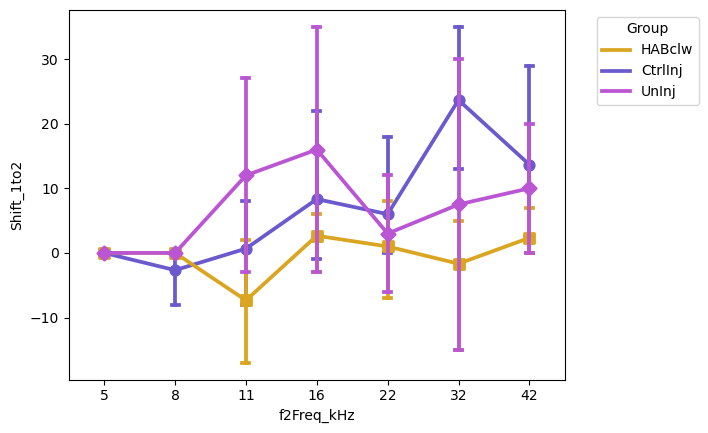

In [19]:
ax = sns.pointplot(dfDPShifts, x='f2Freq_kHz', y='Shift_1to2',hue='InjGroup', errorbar='ci',markers=["o", "s", "D"], 
              linestyles=["-", "-","-"], capsize=.1,palette=colors)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=conditions)
leg = ax.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
plt.savefig(dirDPOAEs+prepID+'.DPOAEThresholdShift.Shift_1to3.png',  bbox_inches='tight', dpi = 300,format = 'png')

In [15]:
# *** CALCULATE ABR THRESHOLD SHIFTS ***
# Iterate through all of the animals
dfABRShifts = pd.DataFrame()
for an in dfABRThs['AnimalID'].unique():
    # Iterate through the number of shifts to calculate
    for i in range(len(daaRuns)-1):
        # Iterate through the frequencies  
        freqs = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==daaRuns[i+1])]['Freq_kHz']
        for freq in freqs:
            # Get the threshold for this animal/freq combo at the next DAA_Run
            thSt = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==daaRuns[i])&(dfABRThs['Freq_kHz']==freq)]['Th_dB_Blinded'].values[0]
            thEnd = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==daaRuns[i+1])& (dfABRThs['Freq_kHz']==freq)]['Th_dB_Blinded'].values[0]
            thShift = thEnd - thSt

            # Get the wave I amplitude at 80 dB
            woSt = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==daaRuns[i])&(dfABRThs['Freq_kHz']==freq)]['W1uV_80dB'].values[0]
            woEnd = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==daaRuns[i+1])& (dfABRThs['Freq_kHz']==freq)]['W1uV_80dB'].values[0]
            woChange = woEnd - woSt
            
            if (len(daaRuns)==2):
                # There are only two time points and the final threshold shift is just the thShift
                thShiftFinal = thShift
            elif ((len(daaRuns)>2)&(i == (len(daaRuns)-2))):
                # This is the final calculation 
                thSt = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==1)& (dfABRThs['Freq_kHz']==freq)]['Th_dB_Blinded'].values[0]
                thShiftFinal = thEnd-thSt

            # Create a subset of the original df to build on 
            dfSS = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==i+1)&(dfABRThs['Freq_kHz']==freq)].copy()
            dfSS['Shift_'+str(i+1)+'to'+str(i+2)] = thShift
            dfSS['W1Change_'+str(i+1)+'to'+str(i+2)+'_uV'] = woChange
            dfSS['Shift_Final'] = thShiftFinal 
            dfABRShifts = pd.concat([dfABRShifts, dfSS])

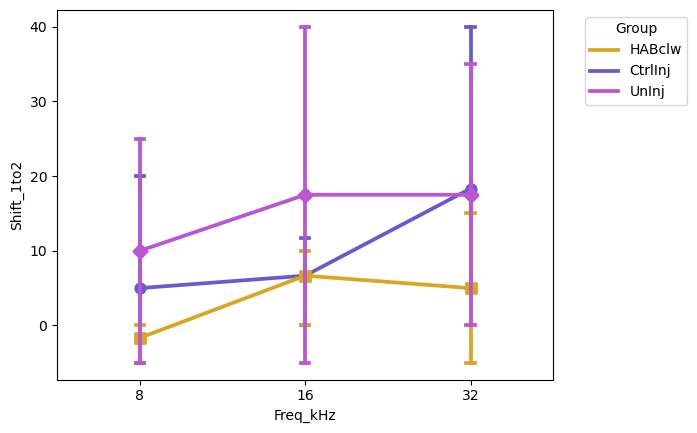

In [21]:
ax = sns.pointplot(data=dfABRShifts,x='Freq_kHz', y='Shift_1to2', hue='InjGroup',markers=["o", "s", "D"], linestyles=["-", "-","-"],
                   errorbar='ci', capsize=.05, palette=colors)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=conditions)
leg = ax.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
plt.savefig(dirGpABRPlts+prepID+'.ABRThresholdShift.Shift_1to3.png',  bbox_inches='tight', dpi = 300,format = 'png')

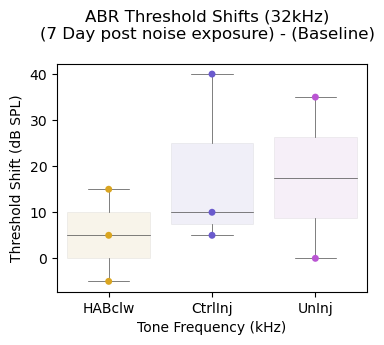

In [38]:
#dfABRShifts['Shift']=dfABRShifts['Shift_Final'].astype(float)
# Parameters for plotting
conditions = ["HABclw","CtrlInj","UnInj"]
pltOrder = conditions
colors = {pltOrder[0]:'goldenrod' , pltOrder[1]:'slateblue', pltOrder[2]:'mediumorchid'}
legColors = ["goldenrod", "slateblue","mediumorchid"]
# tdTom(+) threshold - Threshold for a synapse to be considered associated with tdTom+ fiber
tdTomThre = 0.18


# *** SET PLOT SPECIFIC PARAMETERS ***
plot = 'ABRThresholdShift.Lineplot.Shift_1to3'
plottype = 'BoxSwarm'
title = 'ABR Threshold Shifts (32kHz)\n(7 Day post noise exposure) - (Baseline)'
hue = 'InjGroup'
x = 'InjGroup'
y = 'Shift_Final'
ymin = -5
ymax = 45
xlab = 'Tone Frequency (kHz)'
ylab = 'Threshold Shift (dB SPL)'

# *** MAKE PLOT ***
fig= plt.figure(figsize=(4,3))
plt.subplots_adjust(top = 0.8, bottom=0.04, hspace=.3, wspace=.2)
fig.suptitle(title)
ax1 = sns.swarmplot(data=dfABRShifts[dfABRShifts['Freq_kHz']==32],x=x,y=y, hue=hue,palette=colors,order=pltOrder,legend = False, dodge = False)
sns.boxplot(data=dfABRShifts[dfABRShifts['Freq_kHz']==32],x=x,y=y, hue=hue,palette=colors,order=pltOrder,boxprops={'alpha': 0.1}, ax=ax1, dodge = False,linewidth=.5)
#ax1.set_ylim((ymin, ymax))
ax1.set(xlabel=xlab)
ax1.set(ylabel=ylab)
ax1.get_legend().remove()

plt.savefig(dirGpABRPlts+prepID+'.ABRThresholdShift.BoxSwarm.32kHz.Shift_1to3.png',  bbox_inches='tight', dpi = 300,format = 'png')

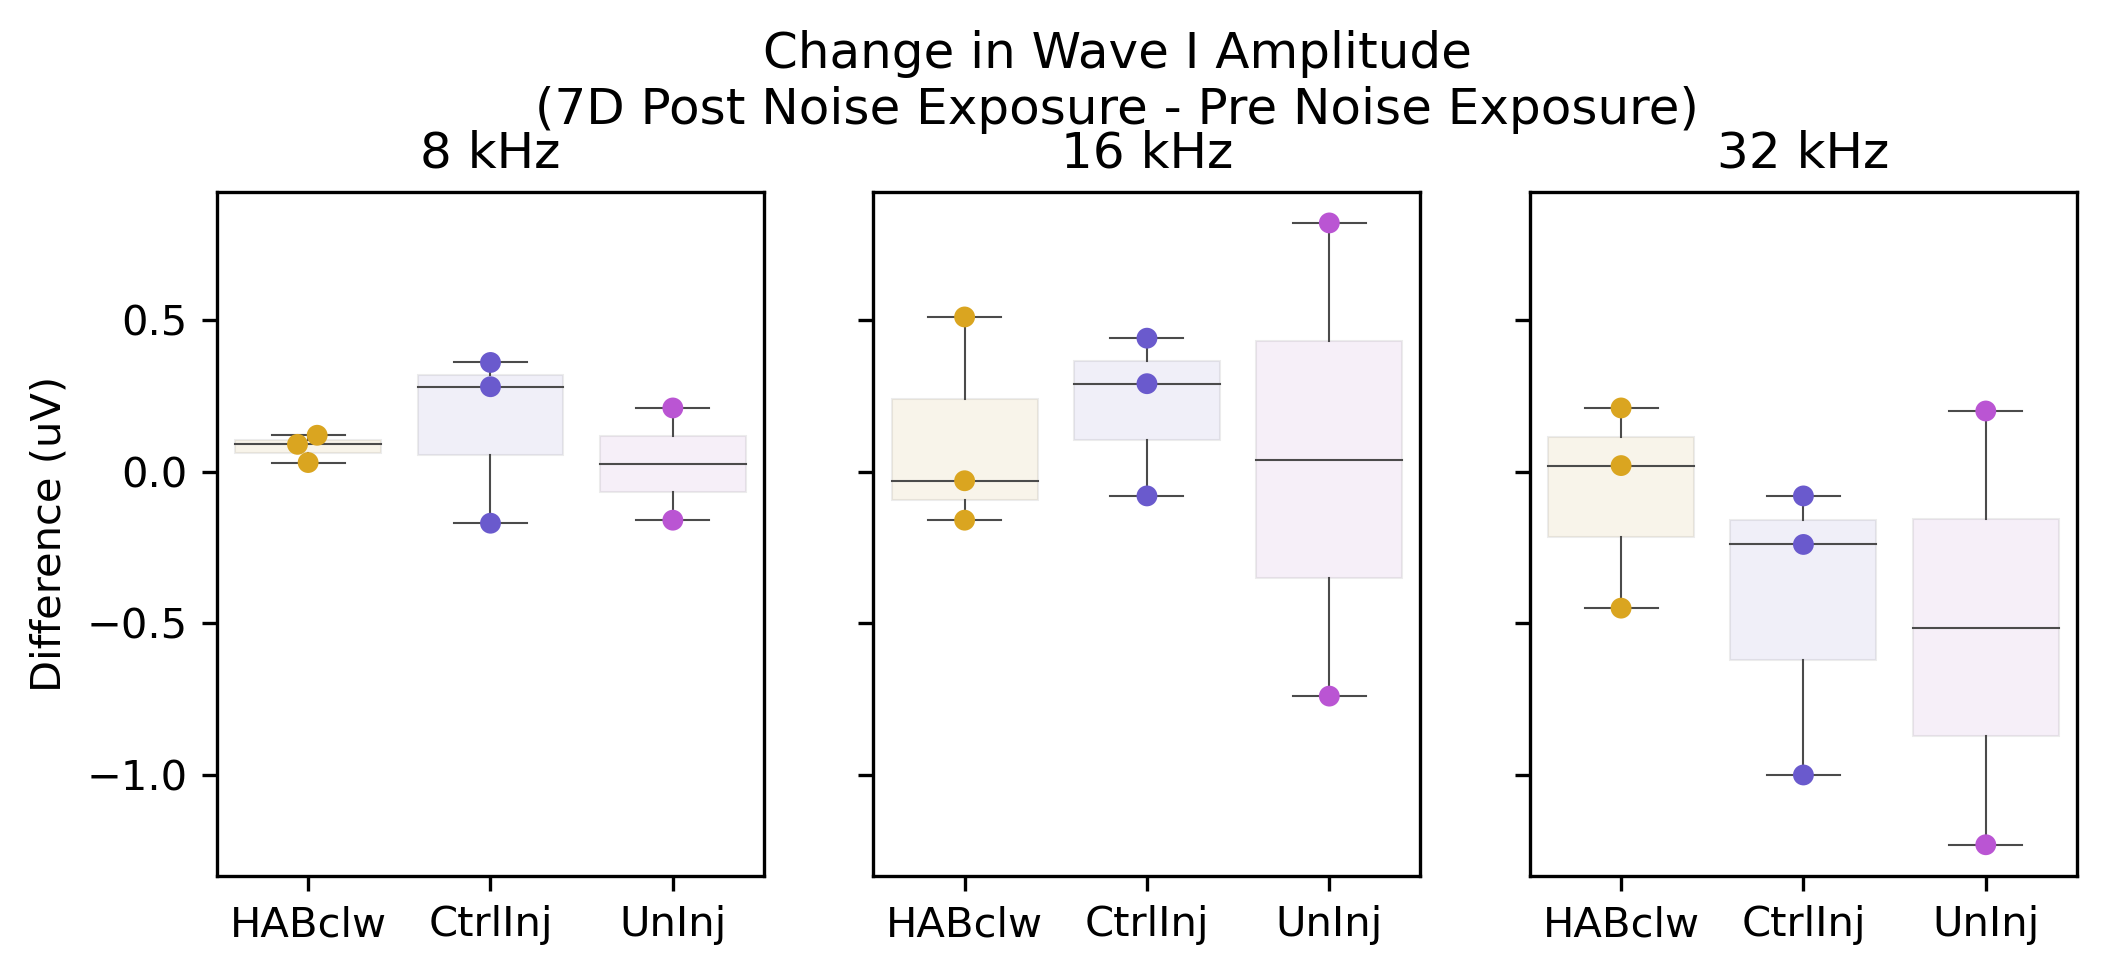

In [17]:

# Parameters for plotting
conditions = ["HABclw","CtrlInj","UnInj"]
pltOrder = conditions
colors = {pltOrder[0]:'goldenrod' , pltOrder[1]:'slateblue', pltOrder[2]:'mediumorchid'}
legColors = ["goldenrod", "slateblue","mediumorchid"]
# tdTom(+) threshold - Threshold for a synapse to be considered associated with tdTom+ fiber
tdTomThre = 0.18


# *** SET PLOT SPECIFIC PARAMETERS ***
plot = 'ABRThresholdShift.Lineplot.Shift_1to3'
plottype = 'BoxSwarm'
title = 'Change in Wave I Amplitude\n(7D Post Noise Exposure - Pre Noise Exposure)'
hue = 'InjGroup'
x = 'InjGroup'
y = 'W1Change_1to2_uV'
ymin = -5
ymax = 45
xlab = ''
ylab = 'Difference (uV)'

# *** MAKE PLOT ***
fig, axes = plt.subplots(1, 3, dpi=300,figsize=(8,3), sharex = True, sharey = True)
(ax1, ax2, ax3) = axes
fig.suptitle(title)
plt.subplots_adjust(top = 0.8, bottom=0.04, hspace=.4, wspace=.2)

ax1 = plt.subplot(131) 
ax1.set_title('8 kHz')
ax1 = sns.swarmplot(data=dfABRShifts[dfABRShifts['Freq_kHz']==8],x=x,y=y, hue=hue,palette=colors,order=pltOrder,legend = False, dodge = False)
sns.boxplot(data=dfABRShifts[dfABRShifts['Freq_kHz']==8],x=x,y=y, hue=hue,palette=colors,order=pltOrder,boxprops={'alpha': 0.1}, ax=ax1, dodge = False,linewidth=.5)
#ax1.set_ylim((ymin, ymax))
ax1.set(xlabel=xlab)
ax1.set(ylabel=ylab)
ax1.get_legend().remove()

ax2 = plt.subplot(132)
ax2.set_title('16 kHz')
ax2 = sns.swarmplot(data=dfABRShifts[dfABRShifts['Freq_kHz']==16],x=x,y=y, hue=hue,palette=colors,order=pltOrder,legend = False, dodge = False)
sns.boxplot(data=dfABRShifts[dfABRShifts['Freq_kHz']==16],x=x,y=y, hue=hue,palette=colors,order=pltOrder,boxprops={'alpha': 0.1}, ax=ax2, dodge = False,linewidth=.5)
#ax2.set_ylim((ymin, ymax))
ax2.set(xlabel=xlab)
ax2.set(ylabel='')
ax2.get_legend().remove()

ax3 = plt.subplot(133)
ax3.set_title('32 kHz')
ax3 = sns.swarmplot(data=dfABRShifts[dfABRShifts['Freq_kHz']==32],x=x,y=y, hue=hue,palette=colors,order=pltOrder,legend = False, dodge = False)
sns.boxplot(data=dfABRShifts[dfABRShifts['Freq_kHz']==32],x=x,y=y, hue=hue,palette=colors,order=pltOrder,boxprops={'alpha': 0.1}, ax=ax3, dodge = False,linewidth=.5)
#ax3.set_ylim((ymin, ymax))
ax3.set(xlabel=xlab)
ax3.set(ylabel='')
ax3.get_legend().remove()

plt.savefig(dirGpWOPlts+prepID+'.WaveIChange.BoxSwarm.Shift_1to3.png',  bbox_inches='tight', dpi = 300,format = 'png')